In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import numpy as np 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.feature_selection import RFECV
from imblearn.pipeline import Pipeline


##### Data Import #####

In [49]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 

htru2 = fetch_ucirepo(id=372) 
  
# data (as pandas dataframes) 
X = htru2.data.features 
y = htru2.data.targets 
  
# metadata 
print(htru2.metadata) 
  
# variable information 
print(htru2.variables) 


{'uci_id': 372, 'name': 'HTRU2', 'repository_url': 'https://archive.ics.uci.edu/dataset/372/htru2', 'data_url': 'https://archive.ics.uci.edu/static/public/372/data.csv', 'abstract': 'Pulsar candidates collected during the HTRU survey. Pulsars are a type of star, of considerable scientific interest. Candidates must be classified in to pulsar and non-pulsar classes to aid discovery.', 'area': 'Physics and Chemistry', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 17898, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C5DK6R', 'creators': ['Robert Lyon'], 'intro_paper': {'ID': 460, 'type': 'NATIVE', 'title': 'Fifty years of pulsar candidate selection: from simple filters to a new principled real-time classification approach', 'a

In [50]:
X

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306
...,...,...,...,...,...,...,...,...
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910


##### Exploratory Data Analysis #####

In [51]:
y.value_counts() # "1" = "Pulsar" and "0" = "Non-Pulsar" 

class
0        16259
1         1639
Name: count, dtype: int64

In [52]:
y.info() # of type int64

<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   17898 non-null  int64
dtypes: int64(1)
memory usage: 140.0 KB


In [53]:
X.head()

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306


In [8]:
X.shape

(17898, 8)

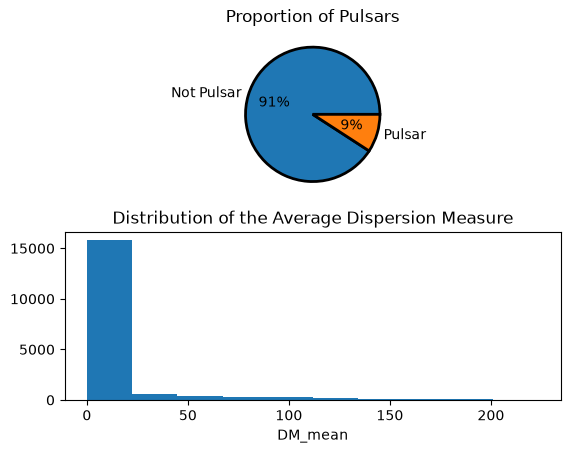

<Figure size 1000x500 with 0 Axes>

In [9]:
df1 = pd.concat([X,y], axis = 1)
fig, (ax1, ax2) = plt.subplots(2)
plt.figure(figsize=(10,5))
# Pie
ax1.pie(y.value_counts(), labels = ["Not Pulsar", "Pulsar"], autopct="%1.0f%%", wedgeprops={'edgecolor': 'black', 'linewidth': 2, 'linestyle': 'solid'})
ax1.set_title("Proportion of Pulsars")


# Histogram
ax2.hist(data=df1, x = "DM_mean", label = "class")
ax2.set_title("Distribution of the Average Dispersion Measure")
ax2.set_xlabel("DM_mean")

plt.tight_layout()

/tmp/ipykernel_10310/3209674407.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df1, x="class", y = "Profile_skewness", palette=["#DC143C", "#0047AB"])


Text(0, 0.5, 'Profile Skewness')

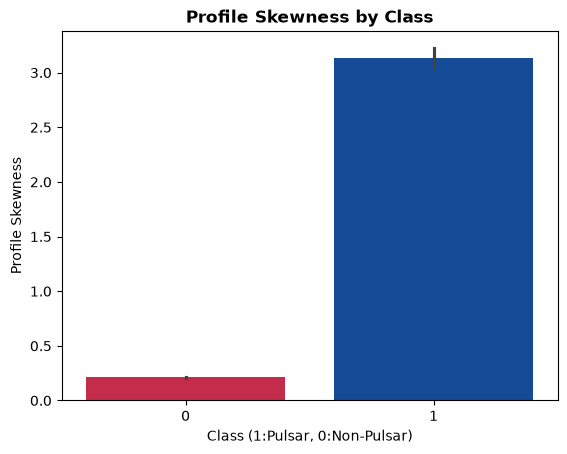

In [10]:

sns.barplot(df1, x="class", y = "Profile_skewness", palette=["#DC143C", "#0047AB"])
plt.title("Profile Skewness by Class", fontweight="bold")
plt.xlabel("Class (1:Pulsar, 0:Non-Pulsar)")
plt.ylabel("Profile Skewness")

In [11]:
""" 
From the graphs, it appears that profile skewness is a good potential indicator of pulsars. 
This is due the asymmetry of the pulse profile. Pulsars typically produce a spike that tapers off 
over some period of time. 
"""

' \nFrom the graphs, it appears that profile skewness is a good potential indicator of pulsars. \nThis is due the asymmetry of the pulse profile. Pulsars typically produce a spike that tapers off \nover some period of time. \n'

Text(0.5, 1.0, 'Profile Mean vs. Std-dev before Balancing')

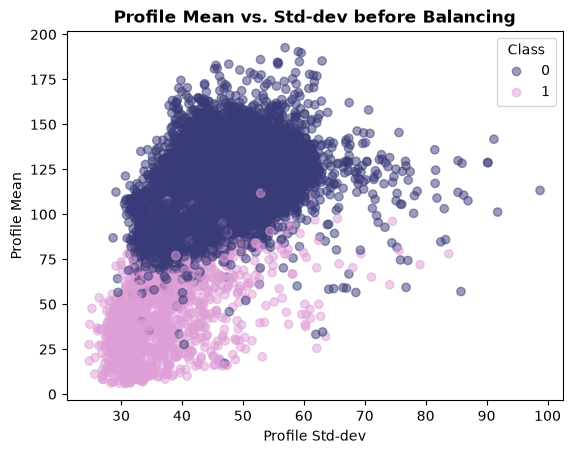

In [12]:
scatter = plt.scatter(x = X["Profile_stdev"], y = X["Profile_mean"], c=y.values, cmap="tab20b", alpha=0.5)
plt.xlabel("Profile Std-dev")
plt.ylabel("Profile Mean")

legend = plt.legend(*scatter.legend_elements(), title="Class")
plt.title("Profile Mean vs. Std-dev before Balancing", fontweight="bold")

In [13]:
""" 
From the plot, we see that pulsars are typically have a lower mean profile. 
This can serve a potential indicator of classifying pulsars. 
"""

' \nFrom the plot, we see that pulsars are typically have a lower mean profile. \nThis can serve a potential indicator of classifying pulsars. \n'

In [14]:
import plotly.express as px

In [15]:
# Class Imbalance needs to be handled

In [16]:
from imblearn.over_sampling import SMOTE

In [17]:
sm = SMOTE(random_state=42) 
X_resampled, y_resampled = sm.fit_resample(X,y)


In [18]:
y_resampled.value_counts() # They now have same amount

class
0        16259
1        16259
Name: count, dtype: int64

In [19]:
df = pd.concat([X_resampled, y_resampled], axis=1)

In [20]:
df

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
...,...,...,...,...,...,...,...,...,...
32513,80.724215,47.016511,1.263814,1.952238,51.973251,74.436661,1.034664,-0.466165,1
32514,12.461454,31.646152,6.015552,37.422362,68.817311,67.020270,0.728766,-0.261396,1
32515,66.591870,45.773232,2.136535,5.341393,142.482255,87.654512,-0.503044,-1.153820,1
32516,70.089223,41.009980,1.586780,4.443027,7.053372,33.415808,5.233680,28.026362,1


In [21]:
# Descriptive Statistics 
df.describe()

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
count,32518.000000,32518.000000,32518.000000,32518.000000,32518.000000,32518.000000,32518.000000,32518.000000,32518.000000
mean,86.648818,42.953470,1.669425,7.961377,29.345349,39.915956,5.806044,65.620035,0.500000
std,38.655231,8.189241,1.980428,12.426393,41.719434,24.661503,4.797198,95.520773,0.500008
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,54.481861,36.456388,0.182325,0.083119,2.485786,17.095539,1.651316,1.657978,0.000000
50%,95.906250,43.492219,0.632150,1.314323,6.807274,32.428520,5.190334,27.462105,0.500000
75%,117.914062,48.860238,2.917068,11.498797,39.429329,62.253139,9.133894,97.954261,1.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


In [22]:
""" 
After performing the resampling method for the imbalanced, dataset, we can that
the descriptive statistics show an average of 0.5 in the class feature. 
"""

' \nAfter performing the resampling method for the imbalanced, dataset, we can that\nthe descriptive statistics show an average of 0.5 in the class feature. \n'

Text(0.5, 1.0, 'Correlations')

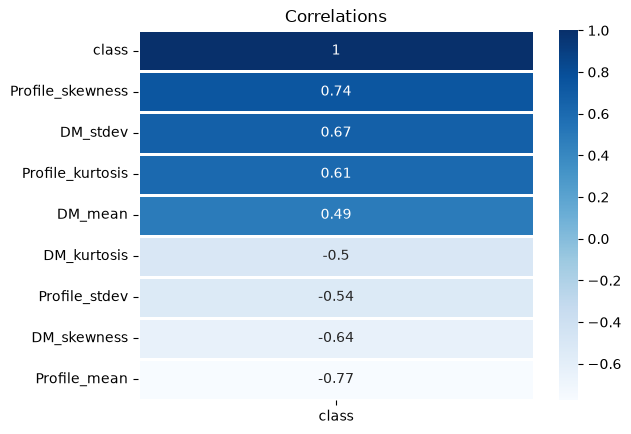

In [23]:
cor_matrix = df.corr()

targ_cor = cor_matrix[["class"]].sort_values(by="class", ascending=False)
sns.heatmap(targ_cor, cmap = "Blues", annot=True, linecolor="white", linewidths= 1)
plt.title("Correlations")

In [24]:
# We see that the profile mean and skewness have the highest correlation values with class. 

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [26]:
X.shape

(17898, 8)

In [27]:
X.shape[1]

8

##### Statistical Analysis #####

In [1]:
# VIF 

def compute_vif(X): 
    vif_data = pd.DataFrame({}) 
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, idx) for idx in range(X.shape[1])]
    return vif_data

In [2]:
vif = compute_vif(X=X)

NameError: name 'X' is not defined

In [3]:
print(vif)

NameError: name 'vif' is not defined

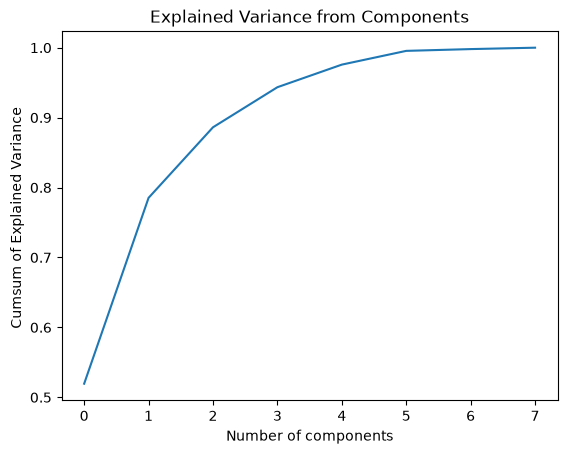

In [31]:
# PCA test
scaler = StandardScaler()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
x_train_scaled = scaler.fit_transform(x_train)
pca = PCA().fit(x_train_scaled, y_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Explained Variance from Components")
plt.xlabel("Number of components")
plt.ylabel("Cumsum of Explained Variance ")
plt.show()

##### ML Pipeline #####

In [51]:
# Hyperparamter Fine Tuning 

from sklearn.model_selection import GridSearchCV

rfc = RandomForestClassifier()
param_set = {
    'n_estimators': [100,200],
    "max_features": ["sqrt",None],
    "max_depth": [None,10,20],
}
gs = GridSearchCV(estimator=rfc, param_grid=param_set,cv=5,n_jobs=-1)
gs.fit(x_train_scaled, y_train)

print(gs.best_params_)

/home/inorris53/Documents/Pulsar/mlprac/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/inorris53/Documents/Pulsar/mlprac/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/inorris53/Documents/Pulsar/mlprac/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/inorris53/Documents/Pulsar/mlprac/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A co

{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}


In [52]:
# Selected HyperParameters: maxdepth(10), maxfeatures(None), nestimators(100)

In [1]:
smote = SMOTE()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
pipe = Pipeline([
    ("smote", smote),
    ("scaler", StandardScaler()),
    ("RFECV", RFECV(cv=cv, estimator=RandomForestClassifier(n_estimators=200, max_depth=10, max_features="sqrt"))), 
    ("rfc", RandomForestClassifier(n_estimators=200, max_depth = 10, max_features="sqrt"))]
)

NameError: name 'SMOTE' is not defined

In [5]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [55]:
pipe.fit(x_train, y_train)

/home/inorris53/Documents/Pulsar/mlprac/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/inorris53/Documents/Pulsar/mlprac/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/inorris53/Documents/Pulsar/mlprac/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/inorris53/Documents/Pulsar/mlprac/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A co

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](8,)","['Profile_mean','Profile_stdev','Profile_skewness',...,'DM_stdev', 'DM_skewness','DM_kurtosis']"
n_features_in_,int,8
,sampling_strategy,'auto'
,random_state,None
,k_neighbors,5


In [56]:
y_pred = pipe.predict(x_test)

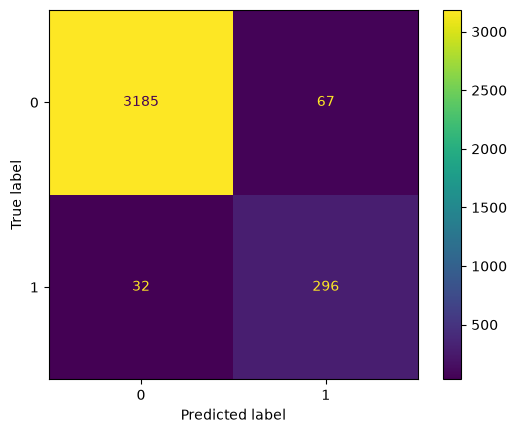

In [57]:
cm = confusion_matrix(y_test, y_pred, labels = pipe.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=pipe.classes_)
disp.plot() 


In [58]:
accuracy_score(y_test, y_pred)

0.9723463687150838

In [59]:
rfc = pipe.named_steps["rfc"]

In [60]:
rfc_feature_importances = pd.DataFrame({"Importance":rfc.feature_importances_, "Labels":pipe.feature_names_in_})

In [61]:
rfc_feature_importances 

,Importance,Labels
0,0.160787,Profile_mean
1,0.022632,Profile_stdev
2,0.355941,Profile_skewness
3,0.189635,Profile_kurtosis
4,0.095748,DM_mean
5,0.087092,DM_stdev
6,0.042455,DM_skewness
7,0.045709,DM_kurtosis


In [ ]:
# The profile skewness has the highest feature importance which confirms it as a viable predictor. 

In [54]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler


In [55]:
Minmax = MinMaxScaler() 

x = Minmax.fit_transform(X)

In [56]:
# Finding the optimal k-means clsuters (Elbow Plot)

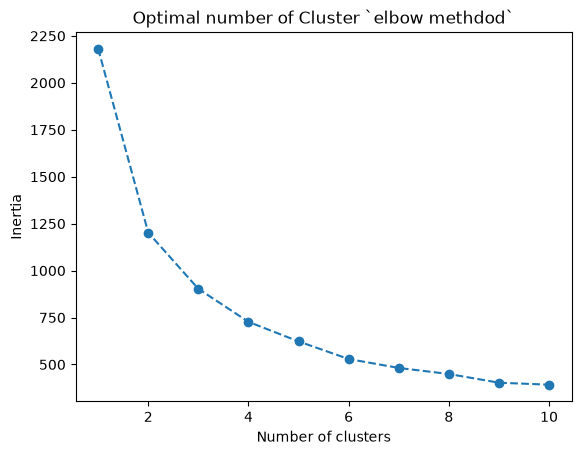

In [103]:
inertias = []
for i in range(1,11): 
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(x)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o', linestyle = "--")
plt.title("Optimal number of Cluster `elbow methdod`")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [104]:
# 2 clusters look optimal 

In [105]:
optimal_c = 2
kmeans_pipeline = Pipeline([
    ("MinMax", MinMaxScaler()), 
    ("K-means", KMeans(optimal_c))
])

In [109]:
pred = kmeans_pipeline.fit_predict(x)

In [110]:
centroids = kmeans_pipeline.named_steps["K-means"].cluster_centers_

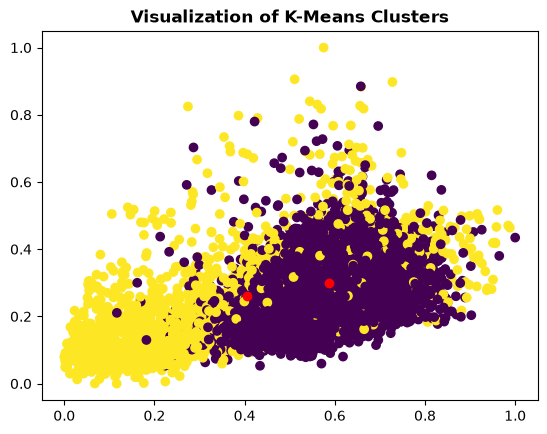

In [124]:
plt.scatter(x[:,0], x[:,1], c = pred)
plt.scatter(centroids[:,0], centroids[:,1], color = "red")
plt.title("Visualization of K-Means Clusters", fontweight = "bold")
plt.show()

In [ ]:
k_means = kmeans_pipeline.named_steps["K-means"]

In [127]:
from sklearn.metrics import adjusted_rand_score

In [130]:
pred.shape

(17898,)

In [ ]:
y.shape

(17898, 1)

In [ ]:
ari = adjusted_rand_score(pred, )

ValueError: labels_pred must be 1D: shape is (17898, 1)